# Этапы проекта

### Постановка бизнес-задачи

#### Выбор компании


Всероссийская сеть магазинов велосипедов "ВелоДрайв" планирует запустить сервис проката в городе Краснодар. Для того, чтобы успешно запуститься, им нужно понять, как именно и насколько сильно влияют на спрос такие факторы, как погодные условия, сезоны, время, а также выходные. Этот анализ также сможет помочь оптимизировать работу, если компания решит разворачивать временные пункты проката вместо стационарных.

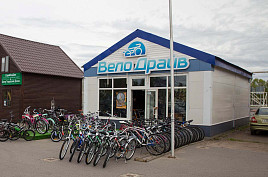

#### Бизнес-задачи

1. Предсказать, в какое время спрос наиболее высок (ВелоДрайву нужно иметь много доступного транспорта, чтобы не терять потенциальную прибыль), а в какое время спрос наиболее низкий (след. можно эффективно проводить техосмотры или вовсе закрывать пункты проката).
2. Предсказать, при какой погоде и в какие календарные периоды наиболее выгодно держать пункты проката открытыми, а при каких условиях пункты проката имеет смысл закрыть.

У нас нет никаких финансовых данных о компании, так что нам придется скорее оценивать риски, чем считать реальные цифры для бизнеса.

#### Планы на дальнейшее развитие

В ближайшем будущем ВелоДрайв планирует сделать мини-приложение и сайт для быстрого бронирования и для долгосрочного бронирования, откуда будет брать данные для дальнейшего предсказания спроса, а соответственно и прибыли, и улучшать предсказания на основе реальных данных прокатов Краснодара. На основе предсказаний спроса можно будет планировать закупки запчастей и обновление велопарка, корректировку часов и периодов работы пунктов выдачи, а тка же планировать бюджет, так что наше решение вписывается прекрасно. Более того, процесс можно применить и к другим городам.

Однако пока что данных из Краснодара нет, мы имеем дело с первым запуском и первичной оценкой, так что будем искать данные в интернете. Естественно, модель, которую мы будем создавать, будет нацелена на поиск и оценку общих закономерностей в динамике спроса и не будет давать иделаьный прогноз для Краснодара: его мы получим только на реальных данных конкретно для этого города. Пока что мы хотим оценить влияние разных факторов на спрос, а уже после запуска можно будет переобучить модель на местных данных.

После запуска проката схема работы будет выглядеть примерно следующим образом:

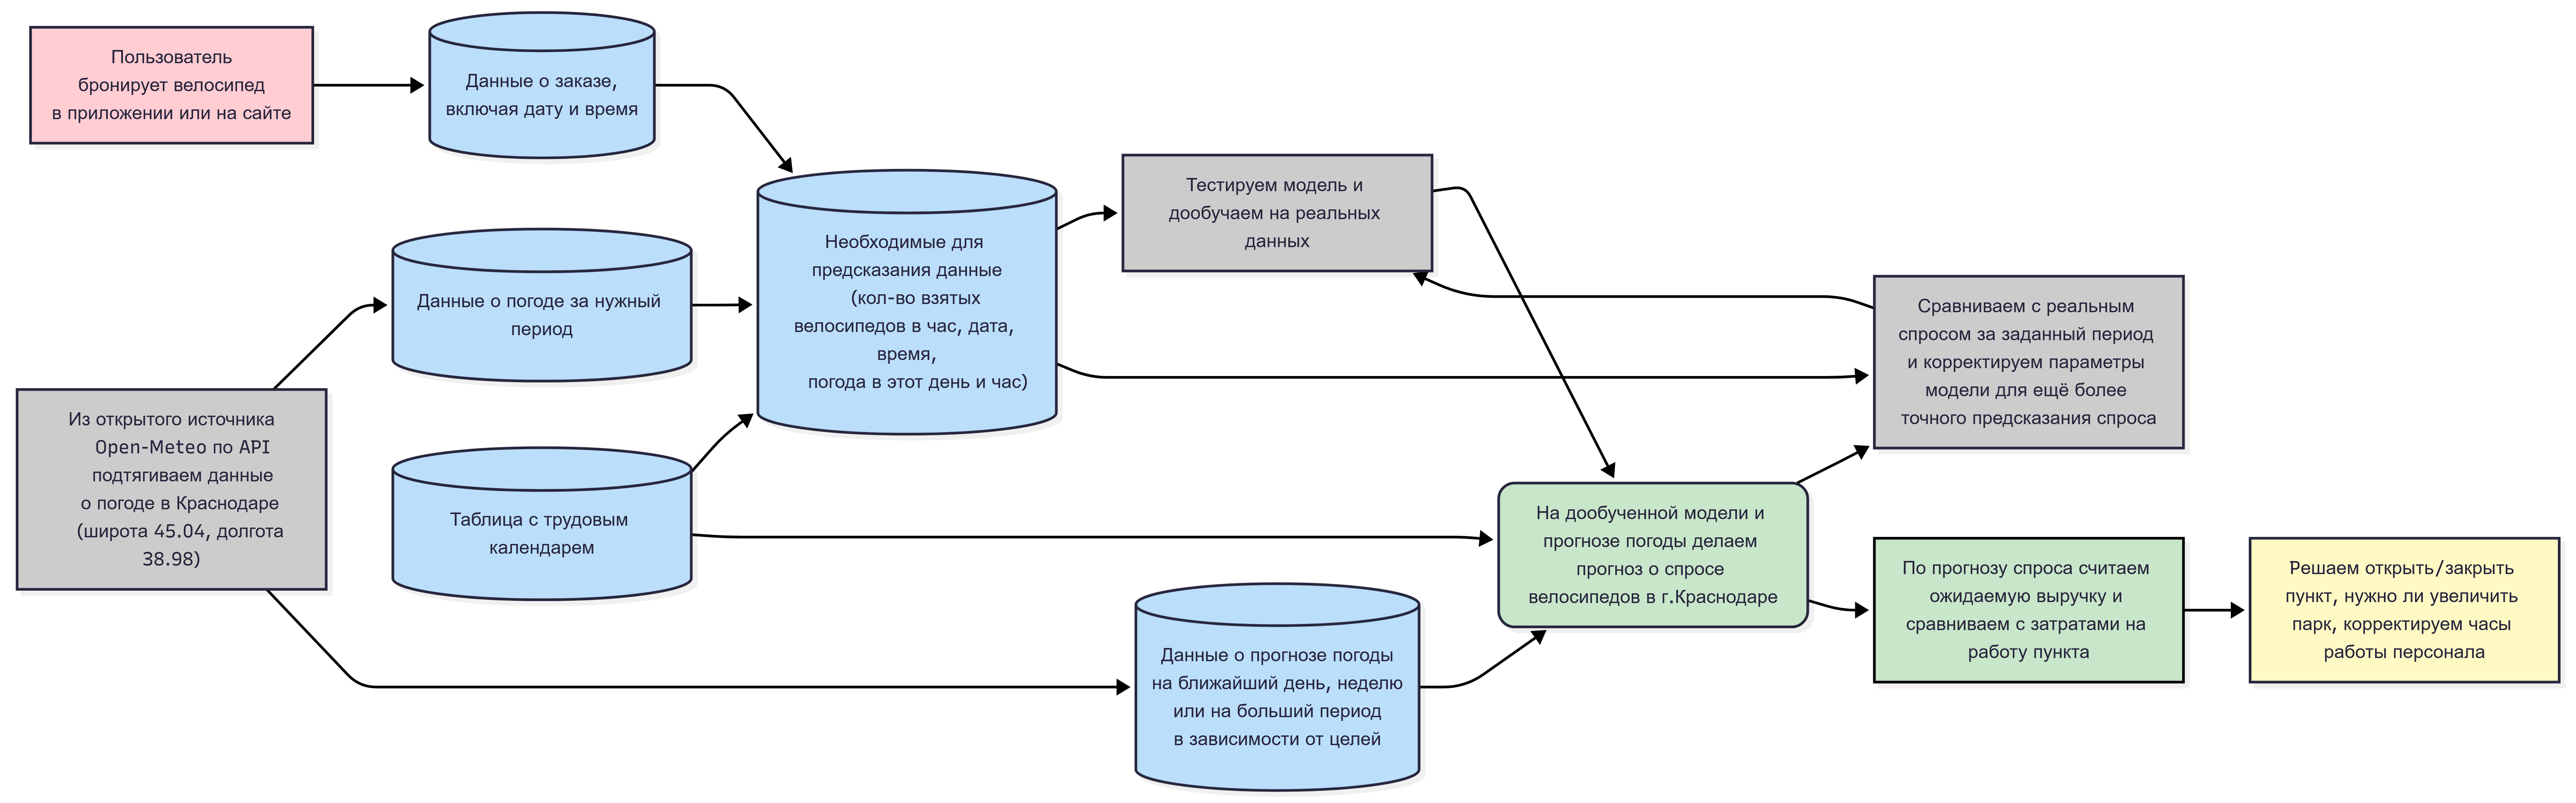

### Исходные данные



#### Описание данных

Для решения этих задач мы взяли открытый датасет Seoul Bike Sharing Demand https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand. Датасет содержит количество общественных велосипедов, взятых напрокат за час в системе велопроката Сеула, с указанием погодных данных и информации о праздничных днях.

Атрибуты
>

*   *Date* - Дата (Date)
*   ***Rented Bike Count* - Кол-во сданных в аренду велосипедов (Integer) - целевая переменная**
*   *Hour* - Время (Integer)
*   *Temperature*	- Температура (Continuous, в градусах по Цельсию)
*   *Humidity* - Влажность (Integer, %)
*   *Wind speed* - Скорость ветра (Continuous, метры в секунду)
*   *Visibility* - Видимость (Integer, на 10 метров)
*   *Dew point temperature*	- Точка росы (Continuous, в градусах по Цельсию). На практике используется для оценки духоты: если выше 20°C, то воздух ощущается тяжелым и липким.
*   *Solar Radiation* - Солнечная радиация (Continuous, Mj/m2 - мегаджоули на квадратный метр)
*   *Rainfall* - Дождь (Integer, мм)
*   *Snowfall* - Снегопад (Integer, см)
*   *Seasons* - Сезон (Categorical)
*   *Holiday* - Выходной (Binary)
*   *Functioning Day* - День работы проката (Binary). **Во всех случаях, когда 0, данные не собирались, так что из датасета нужно удалить строки.**

#### Анализ рынка

Мы понимаем, что на спрос могут влиять и другие факторы, такие как инфраструктура, доход населения и местные цены, численность населения, расположения прокатов и разные бизнес-модели, наконец, культура. Нас здесь скорее интересует общая динамика и предсказание спроса на основе конкретно этих факторов - погоды, времени и выходных.

Мы предполагаем, что люди живут и работают в городах по схожим графикам и что они будут реагировать схожим образом на погоду и календарные события в любом городе мира. Отметим при этом, что Краснодар и Сеул похожи по продолжительности солнечного дня, силе ветра и температуре, разве что в Краснодаре лето чуть менее жаркое и зима в среднем на пару градусов теплее.

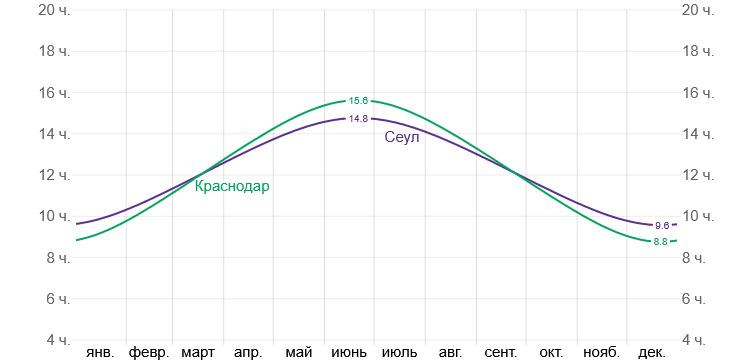

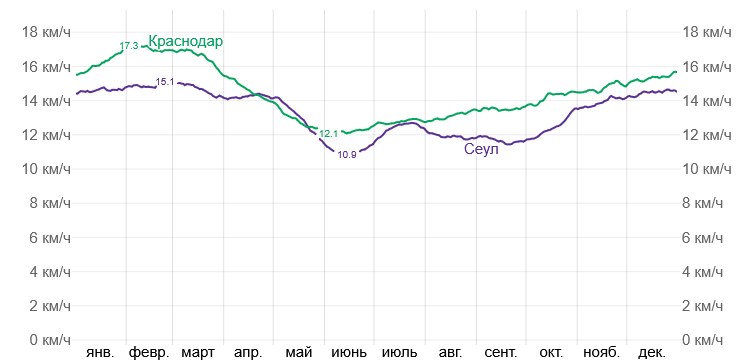

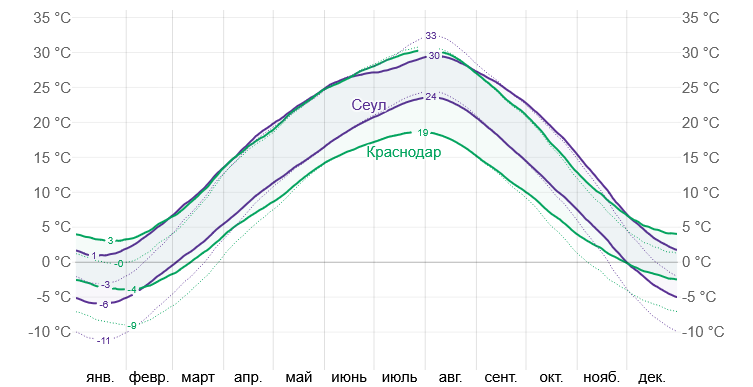

Существенно они отличаются лишь по количеству дождей в летние месяцы (в Сеуле сезон дождей летом) и по толщине снежного покрова зимой (в Сеуле снег практически не выпадает).

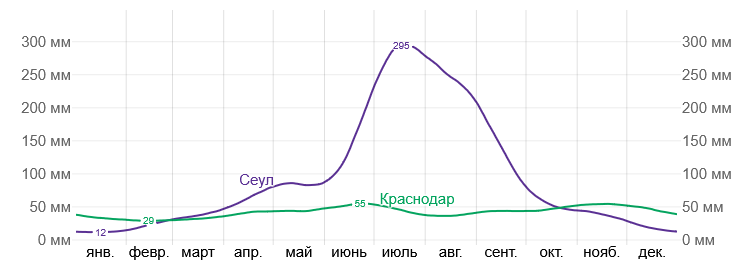

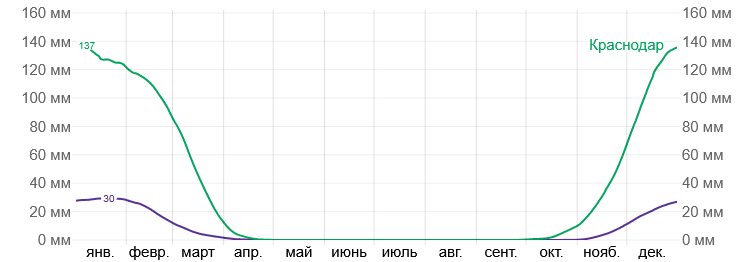

[Население Сеула](https://www.statista.com/statistics/1065290/south-korea-seoul-economically-active-population/)  - 9,6 млн человек; [население Краснодара](https://23.rosstat.gov.ru/population_kk) - 2,3 млн человек, что примерно в 4 раза меньше. Трудоспособное население Сеула - около 5,39 млн человек, а Краснодара - 1,15 млн человек, что в 4,5 раза меньше. Эти данные можно также использовать при первичной оценке кол-ва необходимых велосипедов.

### Постановка задач в терминах машинного обучения, для решения поставленных бизнес-задач


#### Задачи, обоснование выбора модели, метрики

Мы полагаем, что признаки могут иметь разную зависимость, потому мы попробуем модели разной природы и сравним их прогнозы по метрикам качества. 

1. Регрессия: 

- предсказать ожидаемый уровень спроса на прокат велосипедов.

В качестве бейзлайна возьмем средний спрос по часу по сезону. 

Далее возьмем разные по природе модели: линейную регрессию (т.к. ожидаем некоторую линейную взаимосвязь в данных), KNN (т.к. при похожих условиях можно ожидать похожий спрос), Random Forest (т.к. она может отловить нелинейные зависимости, как, к примеру, спрос от температуры в разные часы).

Метрики: MAE (средняя ошибка прогноза), RMSE (сильнее штрафует большие ошибки) и R² (какую долю вариативности спроса объясила модель)

2. Классификация: 

- предсказать категорию спроса (низкий, средний или высокий). Класс спроса создадим по квантилям: Q1 - low, Q1-Q3 - moderate, Q3 - high. 

Бейзлайн сделаем просто как самое часто встречающиеся значение.

Снова возьмем разные по природе модели по тем же причинам соответственно: логистическая регрессия, KNN, Random Forest.

Метрики: accuracy (доля всех правильно угаданных ответов), precision (доля объектов, которые модель отнесла к положительному классу и оказалась права), recall (доля реальных объектов положительного класса, которые смогла обнаружить модель) и F1-score (среднее гармоническое между precision и recall)

### Первичная обработка данных

#### Библиотеки

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

#### Очистка данных

In [2]:
df = pd.read_csv('SeoulBikeData[1].csv', encoding='latin-1')

Преобразовываем в бинарный тип данных для дальнейшего удобства

In [3]:
df['Holiday'] = df['Holiday'].map({'No Holiday': 0, 'Holiday': 1})
df['Functioning Day'] = df['Functioning Day'].map({'Yes': 1, 'No': 0})

In [4]:
df.head(5)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,0,1
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,0,1
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,0,1
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,0,1
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   int64  
 13  Functioning Day            8760 non-null   int64

In [6]:
df.isna().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

Данные не содержат пустых значений

Переименовывем колонки, чтобы упростить процесс работы с ними

In [7]:
df = df.rename(columns={'Temperature(°C)': 'Temperature', 'Humidity(%)': 'Humidity', 'Wind speed (m/s)': 'Wind speed', 'Visibility (10m)': 'Visibility', 'Dew point temperature(°C)': 'Dew point', 'Solar Radiation (MJ/m2)': 'Radiation', 'Snowfall (cm)': 'Snowfall', 'Rainfall(mm)': 'Rainfall'})

Теперь уберем все строки, когда прокат не работал. То есть, когда Functioning Day принимал значение 0

In [8]:
df = df[df['Functioning Day'] != 0]

In [9]:
df

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point,Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,0,1
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,0,1
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,0,1
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,0,1
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,0,1
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,0,1
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,0,1
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,0,1


Для первой задачи для бейзлайна можем взять среднюю долю на час на отдельные сезоны.

Примем допущение, что размер велопарка из датасета - максимальное кол-во единоразово взятых велосипедов:

In [10]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

In [11]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

Сделаем циклическое кодирование для часа/месяцев/дней недели, чтобы каждый час стал точкой на окружности и близкие по времени часы были бы близкими и для модели.
(https://towardsdatascience.com/is-your-model-time-blind-the-case-for-cyclical-feature-encoding/)

In [12]:
df["hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)
df["day_sin"] = np.sin(2 * np.pi * df["Day"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["Day"] / 7)

In [13]:
velopark = df['Rented Bike Count'].max()
velopark

3556

Высчитываем долю арендованных велосипедов 

In [14]:
df['velopark_share'] = df['Rented Bike Count'] / velopark

Разделим спрос на три части по квантилям (25% низкого спроса, потом 50% среднего и потом 25% высокого)

In [15]:
Q1 = df['Rented Bike Count'].quantile(0.25)
Q3 = df['Rented Bike Count'].quantile(0.75)
print(Q1, Q3)

214.0 1084.0


Создадим поле base_class, определяющее класс спроса

In [16]:
def base_class(i):
    if i <= Q1:
        return 'low'
    elif i >= Q3:
        return 'high'
    else:
        return 'moderate'

In [17]:
df['base_class'] = df['Rented Bike Count'].apply(base_class)

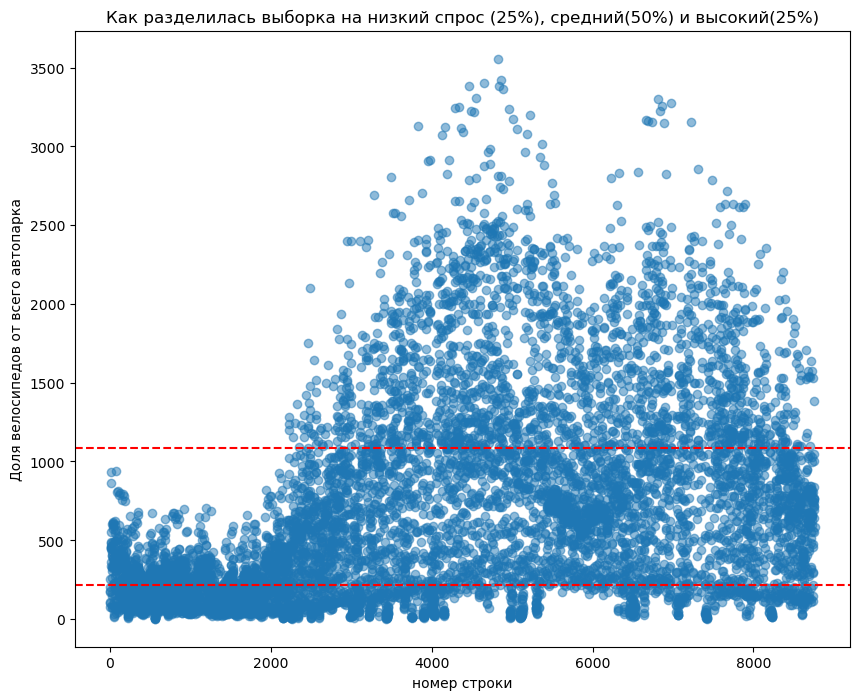

In [18]:
plt.figure(figsize=(10, 8))
plt.scatter(df.index, df['Rented Bike Count'], alpha=0.5)
plt.axhline(Q1, color='red', linestyle='--')
plt.axhline(Q3, color='red', linestyle='--')
plt.xlabel("номер строки")
plt.ylabel("Доля велосипедов от всего автопарка")
plt.title("Как разделилась выборка на низкий спрос (25%), средний(50%) и высокий(25%)")
plt.show()

Дропаем все лишние для модели колонки

In [19]:
df_baseline = df
df_model = df
df = df.drop(columns=['Hour', 'Day', 'Month', 'Functioning Day', 'Date'])

#### Статистическое исследование данных

Посмотрим на корреляцию атрибутов методом Пирсона

In [20]:
df.corr(numeric_only=True).round(2)

,Rented Bike Count,Temperature,Humidity,Wind speed,Visibility,Dew point,Radiation,Rainfall,Snowfall,Holiday,Year,hour_sin,hour_cos,month_sin,month_cos,day_sin,day_cos,velopark_share
Rented Bike Count,1.00,0.56,-0.20,0.13,0.21,0.40,0.27,-0.13,-0.15,-0.07,0.23,-0.45,-0.10,-0.29,-0.40,-0.03,0.01,1.00
Temperature,0.56,1.00,0.17,-0.04,0.03,0.91,0.35,0.05,-0.22,-0.06,0.38,-0.17,-0.12,-0.50,-0.77,0.04,0.02,0.56
Humidity,-0.20,0.17,1.00,-0.34,-0.55,0.54,-0.46,0.24,0.11,-0.05,0.04,0.31,0.29,-0.17,-0.21,0.05,0.01,-0.20
Wind speed,0.13,-0.04,-0.34,1.00,0.18,-0.18,0.33,-0.02,-0.00,0.03,-0.00,-0.38,-0.24,0.17,0.02,-0.03,-0.07,0.13
Visibility,0.21,0.03,-0.55,0.18,1.00,-0.18,0.15,-0.17,-0.12,0.02,0.05,-0.14,-0.02,-0.21,0.01,-0.04,-0.02,0.21
Dew point,0.40,0.91,0.54,-0.18,-0.18,1.00,0.10,0.13,-0.15,-0.07,0.33,-0.01,0.03,-0.50,-0.74,0.05,0.03,0.40
Radiation,0.27,0.35,-0.46,0.33,0.15,0.10,1.00,-0.07,-0.07,-0.00,0.13,-0.19,-0.70,-0.03,-0.22,-0.00,-0.02,0.27
Rainfall,-0.13,0.05,0.24,-0.02,-0.17,0.13,-0.07,1.00,0.01,-0.01,0.03,-0.01,-0.02,-0.03,-0.08,0.03,0.02,-0.13
Snowfall,-0.15,-0.22,0.11,-0.00,-0.12,-0.15,-0.07,0.01,1.00,-0.01,-0.21,0.04,-0.02,0.03,0.22,0.01,-0.09,-0.15
Holiday,-0.07,-0.06,-0.05,0.03,0.02,-0.07,-0.00,-0.01,-0.01,1.00,-0.12,0.00,0.00,0.00,0.07,0.13,-0.04,-0.07


Для наглядности построим [heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

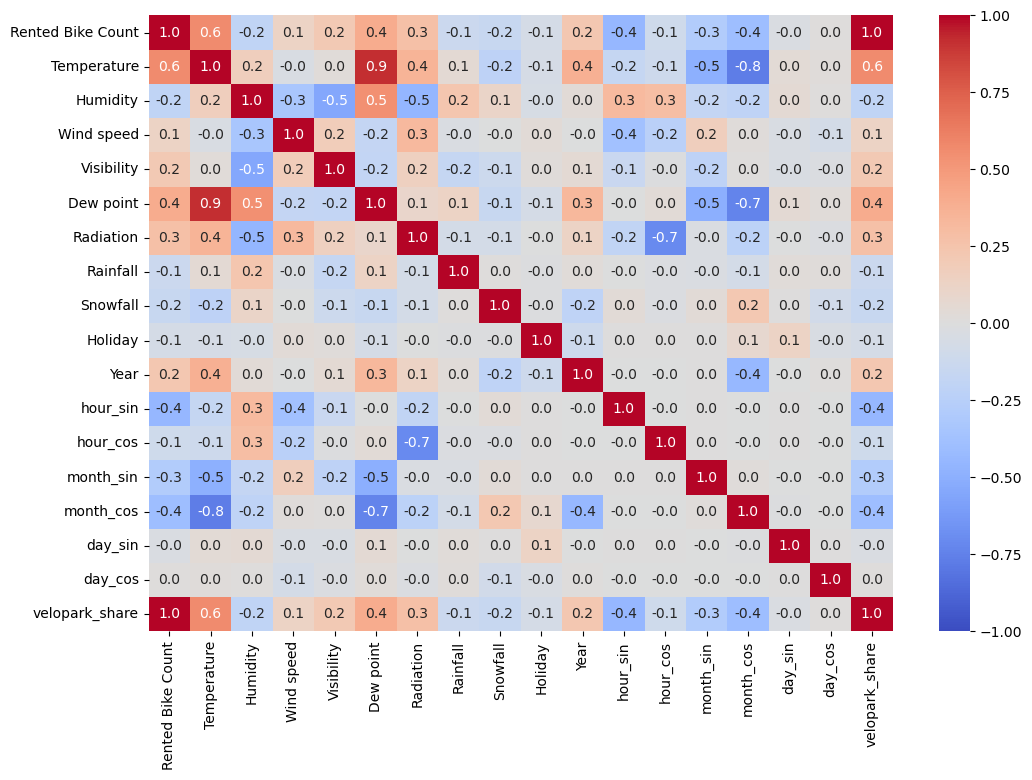

In [21]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    data=df.corr(numeric_only=True),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".1f"
)
plt.show()

Линейная зависимость большинства показателей не прослеживается, однако есть атрибуты с высокой корреляцией.   
Например, прямая линейная зависимость ярко выражена у основных показателей Rented Bike Count и velopark_share, у Temperature и Dew Point, умеренная зависимость между Temperature и Rented Bike Count.  
Обратная линейная зависимость наиболее сильная у month_cos и Temperature, month_cos и Dew Point, hour_cos и Radiation   
При создании train и test датасетов будем убирать факторы с высокой корреляцией, чтобы избавиться от мультиколлинеарности

### Бейзлайн

#### Бейзлайн для регрессии

Разделим для бейзлайна по регрессии данные на test и train

Убираем колонку 'Date', так как она нам больше не пригодится

In [22]:
df_baseline.drop(columns=['Date'])

,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point,Radiation,Rainfall,Snowfall,...,Month,Day,hour_sin,hour_cos,month_sin,month_cos,day_sin,day_cos,velopark_share,base_class
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,...,12,1,0.000000,1.000000,-2.449294e-16,1.000000,0.781831,0.623490,0.071429,moderate
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,...,12,1,0.258819,0.965926,-2.449294e-16,1.000000,0.781831,0.623490,0.057368,low
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,...,12,1,0.500000,0.866025,-2.449294e-16,1.000000,0.781831,0.623490,0.048650,low
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,...,12,1,0.707107,0.707107,-2.449294e-16,1.000000,0.781831,0.623490,0.030090,low
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,...,12,1,0.866025,0.500000,-2.449294e-16,1.000000,0.781831,0.623490,0.021935,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,...,11,30,-0.965926,0.258819,-5.000000e-01,0.866025,0.974928,-0.222521,0.282058,moderate
8756,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,...,11,30,-0.866025,0.500000,-5.000000e-01,0.866025,0.974928,-0.222521,0.214848,moderate
8757,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,...,11,30,-0.707107,0.707107,-5.000000e-01,0.866025,0.974928,-0.222521,0.195163,moderate
8758,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,...,11,30,-0.500000,0.866025,-5.000000e-01,0.866025,0.974928,-0.222521,0.200225,moderate


Унифицированное разделение на тест и трейн для регрессии

In [23]:
X = df_baseline.drop(columns=['velopark_share', 'Rented Bike Count', 'base_class'])
y = df_baseline['velopark_share']
X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(X, y, test_size = 0.2, random_state = 42)

Объединим два получившихся датафрейма, чтобы рассчитать бейзлайн

In [24]:
train = pd.concat([X_train_baseline[['Hour', 'Seasons']], y_train_baseline], axis=1)
baseline = train.groupby(['Hour', 'Seasons'])['velopark_share'].mean()
y_baseline = pd.merge(X_test_baseline[['Hour', 'Seasons']], baseline.reset_index(), on=['Hour', 'Seasons'])['velopark_share']

Рассчитаем метрики

In [25]:
r2_baseline = r2_score(y_test_baseline, y_baseline)
mae_baseline = mean_absolute_error(y_test_baseline, y_baseline)
rmse_baseline = root_mean_squared_error(y_test_baseline, y_baseline)

In [26]:
print(f'Root Mean Squared Error (RMSE): {rmse_baseline}')
print(f'R²: {r2_baseline}')
print(f'Mean Absolute Error (MAE): {mae_baseline}')

Root Mean Squared Error (RMSE): 0.10545275549806982
R²: 0.6418176674781141
Mean Absolute Error (MAE): 0.06958067545375095


Построим график и посмотрим на распределение точек бейзлайна и реальных данных

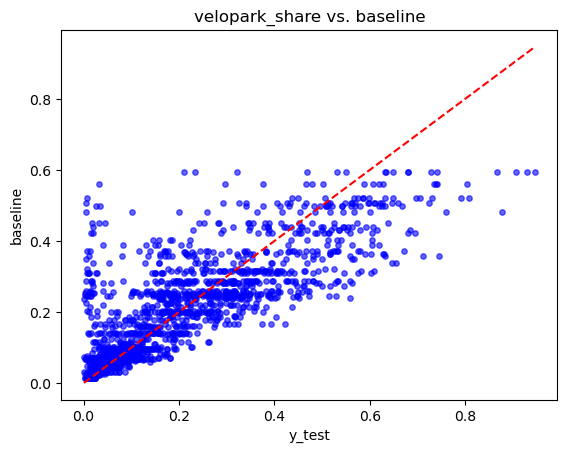

In [27]:
plt.scatter(y_test_baseline, y_baseline, c="blue", marker="o", s=15, alpha=0.6)
plt.xlabel('y_test')
plt.ylabel('baseline')
plt.title('velopark_share vs. baseline')

plt.plot(
   [y_test_baseline.min(), y_test_baseline.max()],
   [y_test_baseline.min(), y_test_baseline.max()],
   'r--'
);

Бейзлайн уже неплохо описывает данные, но посмотрим, получится ли уточнить получившийся результат при помощи моделей машинного обучения

#### Бейзлайн для классификации

In [28]:
X = df_baseline.drop(columns=['velopark_share', 'Rented Bike Count', 'base_class'])
y = df_baseline['base_class']
X_train_baseline_c, X_test_baseline_c, y_train_baseline_c, y_test_baseline_c = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

In [29]:
most_frequent = y_train_baseline_c.value_counts().idxmax()
y_baseline_c = [most_frequent] * len(y_test_baseline_c)
recall = recall_score(y_test_baseline_c, y_baseline_c, average='macro')
print(recall)

0.3333333333333333


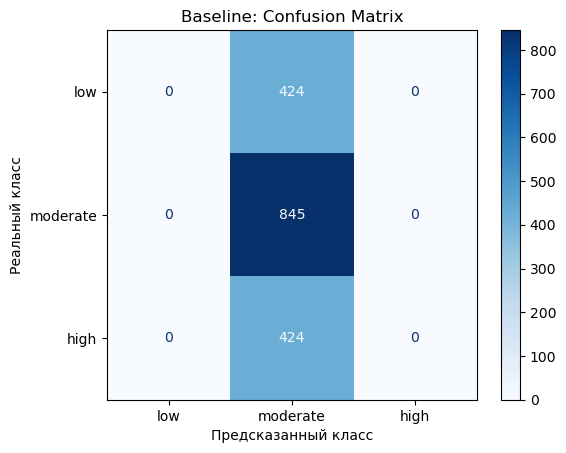

In [30]:
cm = confusion_matrix(y_test_baseline_c, y_baseline_c, labels=["low", "moderate", "high"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["low", "moderate", "high"])
disp.plot(cmap='Blues')

plt.xlabel('Предсказанный класс')
plt.ylabel('Реальный класс')
plt.title("Baseline: Confusion Matrix")
plt.show()

Результат был ожидаемым, так как в данной задаче вы выбираем наиболее часто встречающийся класс, moderate, так как он по условию 50%

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html

In [31]:
df_model = df_model.drop(columns=['Date'])

Применяем one-hot encoding для разбивки сезонов на бинарные признаки

In [32]:
categorical_columns = df_model.select_dtypes(include='object').columns.drop('base_class')

In [33]:
categorical_columns

Index(['Seasons'], dtype='object')

In [34]:
df_model = df_model.reset_index(drop=True)

In [35]:
encoder = OneHotEncoder(sparse_output=False)
enc_data = encoder.fit_transform(df_model[categorical_columns])
enc_df = pd.DataFrame(enc_data, columns=encoder.get_feature_names_out(categorical_columns))
df_model = pd.concat([df_model.drop(columns=categorical_columns), enc_df], axis=1)

In [36]:
df_model = df_model.rename(columns={'Seasons_Autumn': 'Autumn', 'Seasons_Spring': 'Spring', 'Seasons_Summer': 'Summer', 'Seasons_Winter': 'Winter'})

## Применение методов машинного обучения для решения поставленных задач

### Регрессионные модели

Сделаем унифицированное разделение на тест и трейн. Делаем сплит вновь, поскольку здесь сезоны уже с one-hot encoding, а в данных для бейзлайна - без него. Модель не сможет обучиться без one-hot. Используем random_state=42, чтобы данные поделились одинаково

Кроме того, убираем из данных колонки, которые могут повлечь за собой мультиколлинеарность. В нашем случае это Rented Bike Count, которая будет коррелировать с velopark_share, поскольку участвует в формуле расчета доли

Предсказываем столбец "velopark_share". В Х кладём все признаки кроме искомого объекта

In [37]:
df_model.columns

Index(['Rented Bike Count', 'Hour', 'Temperature', 'Humidity', 'Wind speed',
       'Visibility', 'Dew point', 'Radiation', 'Rainfall', 'Snowfall',
       'Holiday', 'Functioning Day', 'Year', 'Month', 'Day', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos',
       'velopark_share', 'base_class', 'Autumn', 'Spring', 'Summer', 'Winter'],
      dtype='object')

In [38]:
X = df_model.drop(columns=['velopark_share', 'Rented Bike Count', 'base_class', 'Day', 'Month', 'Hour'])
y = df_model['velopark_share']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [39]:
X.columns

Index(['Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Dew point',
       'Radiation', 'Rainfall', 'Snowfall', 'Holiday', 'Functioning Day',
       'Year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_sin',
       'day_cos', 'Autumn', 'Spring', 'Summer', 'Winter'],
      dtype='object')

#### KNN Регрессия

В итоге обучения мы хотим получить долю велопарка, которая, мы предполагаем, будет востребована.

Метод берёт данные для ближайших соседей по эвклидову расстоянию и усредняет количество использованных велосипедов.

Мы определяем оптимальное количество соседей, по которым будем рассчитывать среднее значение (делим количество велосипедов на количество соседей)

Применим PCA чтобы снизить размерность и избежать мультиколлинеарности и проклятия размерности (например, если не отмасштабировать данные, то какие-то признаки могут начать доминировать над другими)

In [40]:
best_k = 0
best_pca_components = 0
best_r2 = 0

pca_components_list = []
n_neighbors_list = []
r2_list = []

for pca_components in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
  for n_neighbors in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    scaler = StandardScaler()
    scaler.fit(X_train_r)
    X_train_normed = scaler.transform(X_train_r)
    X_test_normed = scaler.transform(X_test_r)

    pca = PCA(pca_components)
    pca.fit(X_train_normed)

    X_train_pca = pca.transform(X_train_normed)
    X_test_pca = pca.transform(X_test_normed)

    model = KNeighborsRegressor(n_neighbors, weights='distance')
    model.fit(X_train_pca, y_train_r)
    y_pred = model.predict(X_test_pca)

    r2 = r2_score(y_test_r, y_pred)

    pca_components_list.append(pca_components)
    n_neighbors_list.append(n_neighbors)
    r2_list.append(r2)

    if r2 > best_r2:
      best_r2 = r2
      best_k = n_neighbors
      best_pca_components = pca_components

print("Лучшее количество компонент PCA =", best_pca_components)
print("Лучшиее кол-во соседей =", best_k)
print("Лучший R² =", best_r2)

Лучшее количество компонент PCA = 10
Лучшиее кол-во соседей = 3
Лучший R² = 0.8274000330146735


Посмотрим на графике

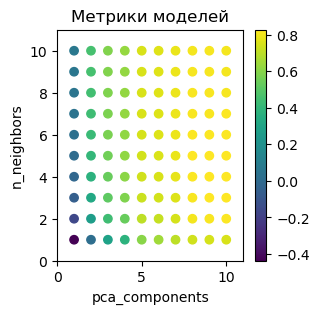

In [41]:
plt.figure(figsize=(3, 3))

color_graph = plt.scatter(pca_components_list, n_neighbors_list, c=r2_list)
plt.xlim((0, 11))
plt.ylim((0, 11))
plt.colorbar(color_graph)
plt.xlabel('pca_components')
plt.ylabel('n_neighbors')
plt.title('Метрики моделей')
plt.show()

Далее воспользуемся полученной информацией о лучших параметрах и обучим нашу модель на них

In [42]:
scaler = StandardScaler()
scaler.fit(X_train_r)
X_train_normed = scaler.transform(X_train_r)
X_test_normed = scaler.transform(X_test_r)

pca = PCA(n_components=best_pca_components)
pca.fit(X_train_normed)

X_train_pca = pca.transform(X_train_normed)
X_test_pca = pca.transform(X_test_normed)

In [43]:
knn = KNeighborsRegressor(best_k, weights="distance")
knn.fit(X_train_pca, y_train_r)
y_pred = knn.predict(X_test_pca)

r2_knn_r = r2_score(y_test_r, y_pred)
rmse_knn_r = root_mean_squared_error(y_test_r, y_pred)
mae_knn_r = mean_absolute_error(y_test_r, y_pred)
print(f'Root Mean Squared Error (RMSE): {rmse_knn_r}')
print(f'R²: {r2_knn_r}')
print(f'Mean Absolute Error (MAE): {mae_knn_r}')

Root Mean Squared Error (RMSE): 0.07320254941133476
R²: 0.8274000330146735
Mean Absolute Error (MAE): 0.044913023951474215


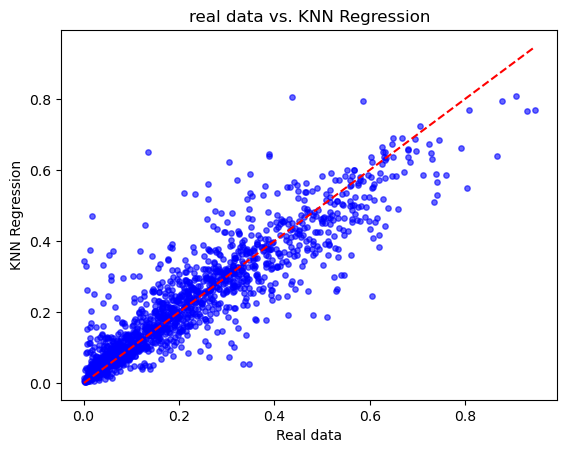

In [44]:
plt.scatter(y_test_r, y_pred, c="blue", marker="o", s=15, alpha=0.6)
plt.xlabel('Real data')
plt.ylabel('KNN Regression')
plt.title('real data vs. KNN Regression')

plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--');

In [45]:
comparison = pd.DataFrame({'Model': ['Baseline', 'KNN Regression'], 'R²': [r2_baseline, r2_knn_r], 'RMSE': [rmse_baseline, rmse_knn_r], 'MAE': [mae_baseline, mae_knn_r]})
comparison

,Model,R²,RMSE,MAE
0,Baseline,0.641818,0.105453,0.069581
1,KNN Regression,0.827400,0.073203,0.044913


Выводы

В среднем модель ошибается на 0.0449 пункта доли арендованных велосипедов (MAE = 0.0449) - Примерно 5%.

В данных присутствуют отдельные наблюдения, где ошибка модели значительно больше средней. RMSE показывает, что с учётом таких крупных ошибок среднее отклонение составляет RMSE = 0.0732.

Модель объясняет примерно 82.7% вариации доли арендованных велосипедов.

#### Линейная регрессия

Применим модель линейной регрессии

In [46]:
model = LinearRegression()
model.fit(X_train_r, y_train_r)

LinearRegression()

In [47]:
y_pred = model.predict(X_test_r)

In [48]:
r2_lr = r2_score(y_test_r, y_pred)
rmse_lr = root_mean_squared_error(y_test_r, y_pred)
mae_lr = mean_absolute_error(y_test_r, y_pred)

print(f'Root Mean Squared Error (RMSE): {rmse_lr}')
print(f'R²: {r2_lr}')
print(f'Mean Absolute Error (MAE): {mae_lr}')

Root Mean Squared Error (RMSE): 0.11524103227689843
R²: 0.572237632099257
Mean Absolute Error (MAE): 0.08781082659095957


In [49]:
y_pred_train = model.predict(X_train_r)
r2_score(y_train_r, y_pred_train)

0.5644662523777841

На трейне R² показал результат ниже, чем на тесте, однако различие у них минимально, поэтому будем считать, что это допустимо

Рассмотрим график linear regression vs. real data

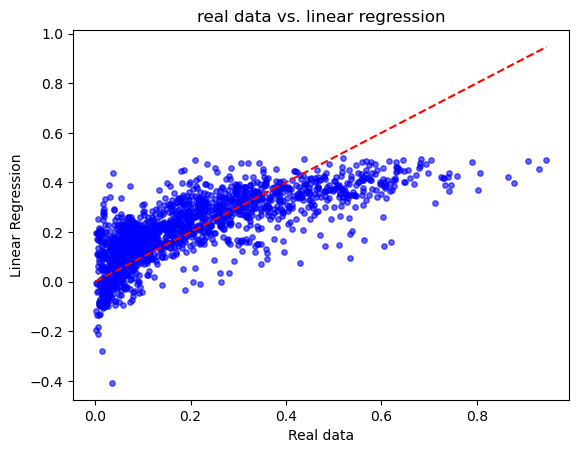

In [50]:
plt.scatter(y_test_r, y_pred, c="blue", marker="o", s=15, alpha=0.6)
plt.xlabel('Real data')
plt.ylabel('Linear Regression')
plt.title('real data vs. linear regression')

plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--');

Отобразим сравнение с бейзлайном

In [51]:
comparison = pd.DataFrame({'Model': ['Baseline', 'Linear Regression'], 'R²': [r2_baseline, r2_lr], 'RMSE': [rmse_baseline, rmse_lr], 'MAE': [mae_baseline, mae_lr]})
comparison

,Model,R²,RMSE,MAE
0,Baseline,0.641818,0.105453,0.069581
1,Linear Regression,0.572238,0.115241,0.087811


Линейная регрессия это процесс моделирования зависимости между зависимой переменной (в нашем случае - velopark_share) и независимыми переменными (seasons, temperature, etc.). В нашем случае можем заметить, что связь между признаками и velopark_share нелинейная, поэтому бейзлайн показал результаты выше. R² показал значение 0.57 - соответственно, модель правильно объясняет лишь 57% изменений спроса. При этом R²
 у бейзлайна несколько выше, соответственно, просто среднее по сгруппированным признакам час и сезон предсказало спрос лучше, чем линейная регрессия, следовательно, стоит рассмотреть другие модели.

https://habr.com/ru/articles/1004248/ - частично отсюда объяснение

#### Random forest regressor

Попробуем обучить модель на Random Forest

Также попробуем применить GreedSearch, чтобы выбрать оптимальные значения для гиперпараметров нашей модели, для того чтобы избежать переобучения или недообучения. 

Для начала зададим сетку параметров. Выберем 100 и 200 количество деревьев (большее число рассматривать не будем, так как датасет не настолько большой, следовательно для экономии ресурсов и времени верхнюю границу выставим 200), максимальную глубину зададим параметрами 5 (простое, но может показать вполне средние результаты) и 10 (достаточная глубина, чтобы уловить сложные зависимости). 

В качестве минимального размера узла для сплита возьмем значение 5 (разбивает большую часть строк в узле, соответственно модель может переобучиться), 10 (среднее значение) и 15 (модель может недообучиться, так как дерево выйдет более простым). Ставим это ограничение, чтобы избежать переобучения, так как дерево может разбиваться бесконечно, пока не останется хотя бы 1 строка. 

Последний параметр - минимальное количество строк, оставшееся в узле: 2 - лист может содержать две строки (это практически переобучение), 5 - лист может содержать 5 строк, среднее значение, 10 - дерево очень простое, шанс недообучения

Источники:
1. https://www.geeksforgeeks.org/machine-learning/performing-feature-selection-with-gridsearchcv-in-sklearn/
2. https://www.geeksforgeeks.org/machine-learning/hyperparameter-tuning/
3. https://sklearner.com/scikit-learn-grid-search-randomforestregressor/
4. https://www.geeksforgeeks.org/machine-learning/random-forest-regression-in-python/

In [52]:
scaler = StandardScaler()
scaler.fit(X_train_r)
X_train_r_scale = scaler.transform(X_train_r)
X_test_r_scale = scaler.transform(X_test_r)
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_train_r_scale, y_train_r)

RandomForestRegressor(random_state=42)

In [53]:
param_grid = {'n_estimators': [100, 200], 'max_depth': [5, 10], 'min_samples_split': [5, 10, 15], 'min_samples_leaf': [2, 5, 10]}

In [54]:
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_r, y_train_r)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10], 'min_samples_leaf': [2, 5, 10],
                         'min_samples_split': [5, 10, 15],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_squared_error')

In [55]:
print(f"Best score: {grid_search.best_score_}")
print(f"Best parameters: {grid_search.best_params_}")

Best score: -0.004065375109761872
Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


Исходя из получившихся результатов можем заметить, что средняя квадратичная ошибка всего 0.004 - что хороший результат. Далее берем лучшие параметры для обучения модели на random forest.

In [56]:
rf_r = grid_search.best_estimator_
y_pred = rf_r.predict(X_test_r)

r2_rf_r = r2_score(y_test_r, y_pred)
rmse_rf_r = root_mean_squared_error(y_test_r, y_pred)
mae_rf_r = mean_absolute_error(y_test_r, y_pred)

print(f'Root Mean Squared Error (RMSE): {rmse_rf_r}')
print(f'R²: {r2_rf_r}')
print(f'Mean Absolute Error (MAE): {mae_rf_r}')

Root Mean Squared Error (RMSE): 0.06368820547280706
R²: 0.8693509309199496
Mean Absolute Error (MAE): 0.03888040835868432


Посмотрим на R² на трейне, чтобы убедиться, что между тестом и трейном есть разрыв в сторону трейна

In [57]:
y_pred_train = rf_r.predict(X_train_r)
r2_score(y_train_r, y_pred_train)

0.9398217908692689

Посмотрим на график деревья решений в сравнении с реальными данными:

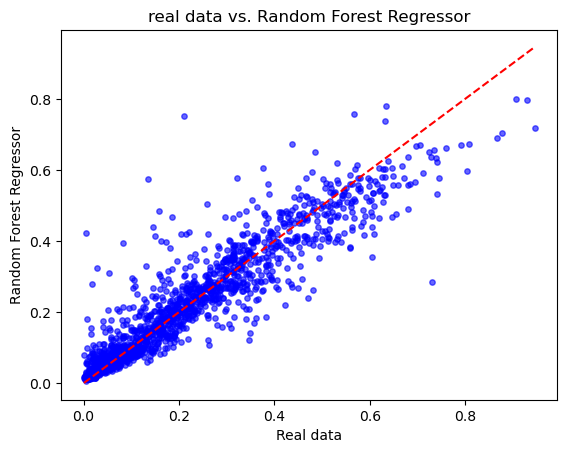

In [58]:
plt.scatter(y_test_r, y_pred, c="blue", marker="o", s=15, alpha=0.6)
plt.xlabel('Real data')
plt.ylabel('Random Forest Regressor')
plt.title('real data vs. Random Forest Regressor')

plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--');

In [59]:
comparison = pd.DataFrame({'Model': ['Baseline', 'Random Forest Regressor'], 'R²': [r2_baseline, r2_rf_r], 'RMSE': [rmse_baseline, rmse_rf_r], 'MAE': [mae_baseline, mae_rf_r]})
comparison

,Model,R²,RMSE,MAE
0,Baseline,0.641818,0.105453,0.069581
1,Random Forest Regressor,0.869351,0.063688,0.038880


Вывод

Random Forest показал хорошие результаты. Исходя из графика можем заметить, что предсказание получилось довольно точным. R² = 0.87, соответственно модель покрывает 87% предсказаний, и мы можем использовать её на проде в качестве ключевой модели

### Классификационные модели

Целевой вопрос: к какому уровню спроса относится наблюдение?    
Целевая переменная: тип спроса (нормальный, низкий или высокий)

In [60]:
print(df["base_class"].value_counts())

base_class
moderate    4224
low         2123
high        2118
Name: count, dtype: int64


Сделаем унифицированное разделение на тест и трейн. Делаем сплит вновь, поскольку здесь сезоны уже с one hot encoding, а в данных для бейзлайна - без него. Модель не сможет обучиться без one hot. Используем random_state=42, чтобы данные поделились одинаково

In [61]:
X = df_model.drop(columns=['velopark_share', 'Rented Bike Count', 'base_class', 'Day', 'Month', 'Hour'])
y = df_model['base_class']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size = 0.2, random_state = 42)

#### KNN Классификация

Применим PCA чтобы снизить размерность и избежать мультиколлинеарности и проклятия размерности (например, если не отмасштабировать данные, то какие-то признаки могут начать доминировать над другими)

In [62]:
best_k_c = 0
best_pca_components_c = 0
best_precision = 0
precision_list = []
pca_components_list_c = []
n_neighbors_list_c = []

for pca_components in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    for k_neighbors in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
        scaler = StandardScaler()
        scaler.fit(X_train_c)
        X_train_c_normed = scaler.transform(X_train_c)
        X_test_c_normed = scaler.transform(X_test_c)

        pca = PCA(pca_components)
        pca.fit(X_train_c_normed)

        X_train_c_pca = pca.transform(X_train_c_normed)
        X_test_c_pca = pca.transform(X_test_c_normed)

        knn_classifier = KNeighborsClassifier(n_neighbors=k_neighbors)
        knn_classifier.fit(X_train_c_pca, y_train_c)
        y_pred_c = knn_classifier.predict(X_test_c_pca)
        precision = precision_score(y_test_c, y_pred_c, average='macro')
        pca_components_list_c.append(pca_components)

        n_neighbors_list_c.append(k_neighbors)
        precision_list.append(precision)
        if precision > best_precision:
            best_precision = precision
            best_k_c = k_neighbors
            best_pca_components_c = pca_components


print("Лучшее количество компонент PCA =", best_pca_components_c)
print("Лучшиее кол-во соседей =", best_k_c)
print("Лучший precision =", best_precision)

Лучшее количество компонент PCA = 9
Лучшиее кол-во соседей = 5
Лучший precision = 0.796074871513643


In [63]:
scaler = StandardScaler()
scaler.fit(X_train_c)
X_train_c_normed = scaler.transform(X_train_c)
X_test_c_normed = scaler.transform(X_test_c)

pca = PCA(best_pca_components_c)
pca.fit(X_train_c_normed)

X_train_c_pca = pca.transform(X_train_c_normed)
X_test_c_pca = pca.transform(X_test_c_normed)

knn_classifier = KNeighborsClassifier(best_k_c)

knn_classifier.fit(X_train_c_pca, y_train_c)
y_pred_c = knn_classifier.predict(X_test_c_pca)

In [64]:
classification_results = []

for weight_type in ["uniform", "distance"]:
    knn_classifier = KNeighborsClassifier(n_neighbors=5, weights=weight_type)
    knn_classifier.fit(X_train_c, y_train_c)
    y_pred_c = knn_classifier.predict(X_test_c)
    accuracy = accuracy_score(y_test_c, y_pred_c)
    classification_results.append([weight_type, accuracy])

classification_results_df = pd.DataFrame(classification_results, columns=["weights", "Accuracy"])
classification_results_df

,weights,Accuracy
0,uniform,0.629652
1,distance,0.649734


In [65]:
final_knn_classifier = KNeighborsClassifier(n_neighbors=best_k_c, weights="distance")
final_knn_classifier.fit(X_train_c, y_train_c)

final_y_pred_c = final_knn_classifier.predict(X_test_c)
final_accuracy = accuracy_score(y_test_c,final_y_pred_c)

print("Финальная KNN-классификация")
print("Лучший k:", best_k_c)
print("Accuracy:", final_accuracy)

print("Classification report:")
print(classification_report(y_test_c, final_y_pred_c))

Финальная KNN-классификация
Лучший k: 5
Accuracy: 0.6497341996455995
Classification report:
              precision    recall  f1-score   support

        high       0.64      0.58      0.61       427
         low       0.67      0.61      0.64       421
    moderate       0.65      0.70      0.67       845

    accuracy                           0.65      1693
   macro avg       0.65      0.63      0.64      1693
weighted avg       0.65      0.65      0.65      1693



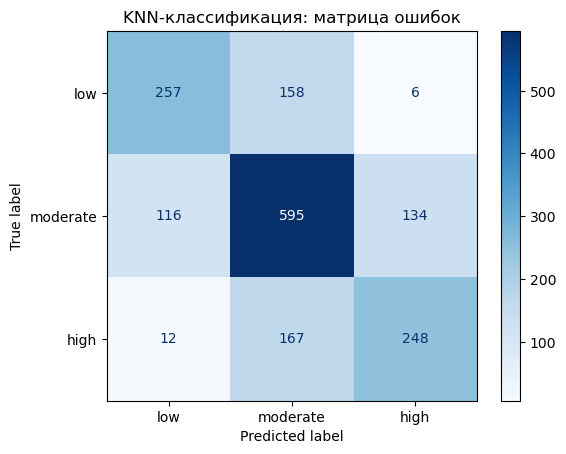

In [66]:
cm = confusion_matrix(y_test_c, final_y_pred_c, labels=["low", "moderate", "high"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["low", "moderate", "high"])
disp.plot(cmap='Blues')
plt.title("KNN-классификация: матрица ошибок")
plt.show()

Среди всех moderate правильно определило 595, low - 257, high - 248

Вывод

Матрица ошибок показывает результаты работы модели KNN-классификации при прогнозировании уровня спроса на велосипеды (Low, Moderate, High). Наибольшее количество объектов было правильно классифицировано для класса Moderate: 595 наблюдений.

Следует отметить, что модель практически не путает классы Low и High между собой, что свидетельствует о хорошем разделении наблюдений с низким и высоким спросом. Основные ошибки возникают на границах между соседними уровнями спроса, что является ожидаемым результатом для алгоритма KNN.

В целом модель продемонстрировала хорошее качество классификации, правильно определив около 70% наблюдений тестовой выборки.

#### Логистическая регрессия

In [67]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_c_pca, y_train_c)

y_pred_lr = model.predict(X_test_c_pca)
precision = precision_score(y_test_c, y_pred_lr, average='macro')

print("Доля правильных ответов precision:", precision)

print(classification_report(y_test_c, y_pred_lr))

Доля правильных ответов precision: 0.6908034548867791
              precision    recall  f1-score   support

        high       0.72      0.67      0.69       427
         low       0.68      0.60      0.64       421
    moderate       0.68      0.73      0.70       845

    accuracy                           0.69      1693
   macro avg       0.69      0.67      0.68      1693
weighted avg       0.69      0.69      0.69      1693



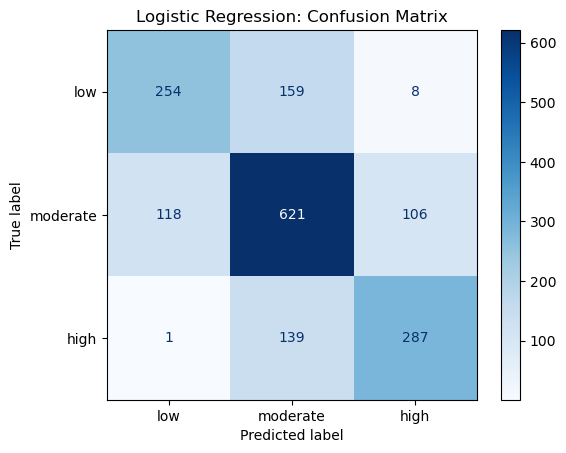

In [68]:
cm = confusion_matrix(y_test_c, y_pred_lr, labels=["low", "moderate", "high"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["low", "moderate", "high"])

disp.plot(cmap='Blues')
plt.title("Logistic Regression: Confusion Matrix")
plt.show()

Среди всех moderate правильно определило 621, low - 254, high - 287

Вывод

Матрица ошибок показывает результаты работы модели Логистической регресии при прогнозировании уровня спроса на велосипеды (Low, Moderate, High). Наибольшее количество объектов было правильно классифицировано для класса Moderate: 621 наблюдение.

Следует отметить, что модель практически не путает классы Low и High между собой, что свидетельствует о хорошем разделении наблюдений с низким и высоким спросом. Основные ошибки возникают на границах между соседними уровнями спроса, что является ожидаемым результатом для алгоритма KNN.

В целом модель продемонстрировала хорошее качество классификации, правильно определив около 73% наблюдений тестовой выборки.

#### Random forest classifier

Задаем параметры для гридсерча

https://www.geeksforgeeks.org/machine-learning/performing-feature-selection-with-gridsearchcv-in-sklearn/

In [69]:
param_grid = {'n_estimators': [100, 200], 'max_features': ['sqrt', 'log2'], 'max_depth': [5, 10], 'criterion': ['gini', 'entropy']}

In [70]:
grid_search_c = GridSearchCV(estimator = RandomForestClassifier(random_state=42), param_grid = param_grid, cv=5, scoring='precision_macro')
grid_search_c.fit(X_train_c, y_train_c)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'], 'max_depth': [5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [100, 200]},
             scoring='precision_macro')

In [71]:
print("Best parameters found: ", grid_search_c.best_params_)
print("Best scoring: ", grid_search_c.best_score_)

Best parameters found:  {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Best scoring:  0.8614162940563853


In [72]:
y_pred_rf = grid_search_c.predict(X_test_c)
print(classification_report(y_test_c, y_pred_rf))

              precision    recall  f1-score   support

        high       0.90      0.84      0.87       427
         low       0.90      0.81      0.85       421
    moderate       0.84      0.91      0.88       845

    accuracy                           0.87      1693
   macro avg       0.88      0.86      0.87      1693
weighted avg       0.87      0.87      0.87      1693



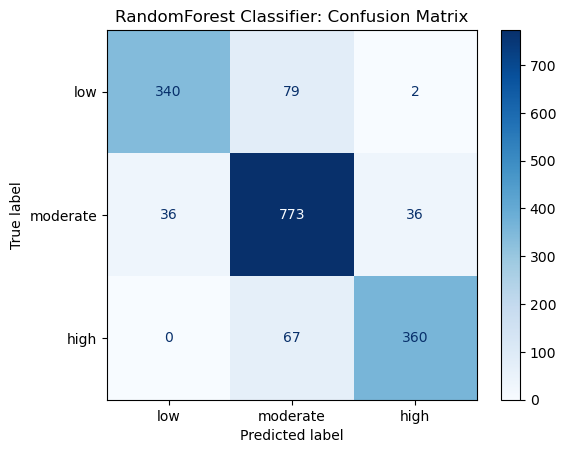

In [73]:
cm = confusion_matrix(y_test_c, y_pred_rf, labels=["low", "moderate", "high"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["low", "moderate", "high"])

disp.plot(cmap='Blues')
plt.title("RandomForest Classifier: Confusion Matrix")
plt.show()

Модель продемонстрировала высокое качество классификации, 90%

# Выводы

## Сводная таблица по моделям

1. Регрессия

In [74]:
regression_metrics = pd.DataFrame({'Model': ['Baseline', 'KNN Regressor', 'Linear Regression', 'Random Forest Regressor'],
                    'R²': [r2_baseline, r2_knn_r, r2_lr, r2_rf_r],
                    'RMSE': [rmse_baseline, rmse_knn_r, rmse_lr, rmse_rf_r],
                    'MAE': [mae_baseline, mae_knn_r, mae_lr, mae_rf_r]})
regression_metrics = regression_metrics.sort_values(by='R²', ascending=False).reset_index(drop=True)
regression_metrics.round(4)

,Model,R²,RMSE,MAE
0,Random Forest Regressor,0.8694,0.0637,0.0389
1,KNN Regressor,0.8274,0.0732,0.0449
2,Baseline,0.6418,0.1055,0.0696
3,Linear Regression,0.5722,0.1152,0.0878


2. Классификация

In [75]:
classification_metrics = pd.DataFrame({'Model': ['KNN Classifier', 'Logistic Regression', 'Random Forest Classifier'],
                    'Accuracy': [accuracy_score(y_test_c, y_pred_c), accuracy_score(y_test_c, y_pred_lr), accuracy_score(y_test_c, y_pred_rf)],
                    'Precision': [precision_score(y_test_c, y_pred_c, average='macro'), precision_score(y_test_c, y_pred_lr, average='macro'), precision_score(y_test_c, y_pred_rf, average='macro')],
                    'Recall': [recall_score(y_test_c, y_pred_c, average='macro'), recall_score(y_test_c, y_pred_lr, average='macro'), recall_score(y_test_c, y_pred_rf, average='macro')],
                    'F1': [f1_score(y_test_c, y_pred_c, average='macro'), f1_score(y_test_c, y_pred_lr, average='macro'), f1_score(y_test_c, y_pred_rf, average='macro')]})
classification_metrics = classification_metrics.sort_values(by='F1', ascending=False).reset_index(drop=True)
classification_metrics.round(4)

,Model,Accuracy,Precision,Recall,F1
0,Random Forest Classifier,0.8701,0.8833,0.8552,0.8674
1,Logistic Regression,0.6864,0.6908,0.6701,0.6790
2,KNN Classifier,0.6497,0.6511,0.6318,0.6402


  1. Бейзлайн
Усредненные значения по часам и сезонам дало значение R²=0,64 . При этом линейная регрессия имеет результат R² = 0,57. Значит можно сделать вывод, что время суток (часы) и сезон важные факторы, влияющие на результат. Но требуется дальнейшее использование других моделей и методов.

  2. Линейная регрессия показала худший результат из всех исследованных моделей.  Это еще раз подтверждает, что связь между погодой, сезоном, временем не является линейной к спросу на велосипеды.

  3. Деревья решений и метод ближайших соседей ( KNN)  превосходят линейные модели. И Random Forest, и KNN показали отличные результаты для задачи регрессии (R² от 0.83 до 0.87).    
  Random Forest оказался лучшей моделью для регрессии, показав самый высокий R² (0.87) и низкие ошибки. Это говорит о том, что данная модель эффективно находит сложные взаимосвязи между признаками.   
  KNN также показал хорошие результаты (0.83), что подтверждает значимость исторических наблюдений: похожие погодные условия и время суток порождают похожий спрос.   
   4. Классификация — более сложная задача. Переводя задачу в классификацию, мы упрощаем предсказание, но точность моделей (0.65 для KNN) немного уступает регрессионным метрикам. Это было ожидаемо, так как мы теряем часть информации, разбивая целевую переменную на группы.

Наиболее точной моделью для предсказания доли арендованных велосипедов является Random Forest Regressor. Эта модель показала лучший результат , так как изучила нелинейные зависимости между погодой, временем и спросом, что делает ее предпочтительным выбором для нашей задачи. Модель успешно обучена и может быть использована для прогнозирования спроса на основе предоставленных признаков.

Далее продемонстрируем расчёт с использованием лучшей модели для интересующего нас города - Краснодар.

Для этого:
1) Вычислим средние значения числовых признаков для каждого часа и сезона
2) Добавим усредненные данные по температурным условиям города
3) С использованием one-hot encoding исследуем каждый сезон
4) Группируем значения

Прогноз спроса на велосипеды в Краснодаре:
Season  Autumn  Spring  Summer  Winter
Hour                                  
0        0.344   0.342   0.366   0.050
1        0.354   0.350   0.344   0.053
2        0.352   0.347   0.339   0.049
3        0.353   0.348   0.340   0.038
4        0.434   0.426   0.405   0.032
5        0.378   0.355   0.351   0.032
6        0.381   0.358   0.355   0.037
7        0.397   0.370   0.363   0.106
8        0.513   0.525   0.485   0.119
9        0.260   0.260   0.282   0.086
10       0.252   0.253   0.266   0.079
11       0.252   0.252   0.267   0.079
12       0.262   0.266   0.339   0.079
13       0.262   0.266   0.341   0.077
14       0.194   0.195   0.304   0.077
15       0.184   0.184   0.290   0.079
16       0.199   0.200   0.324   0.094
17       0.169   0.247   0.297   0.095
18       0.285   0.332   0.448   0.103
19       0.170   0.249   0.304   0.085
20       0.164   0.245   0.255   0.081
21       0.163   0.243   0.252   0.081
22       0.187   0.25

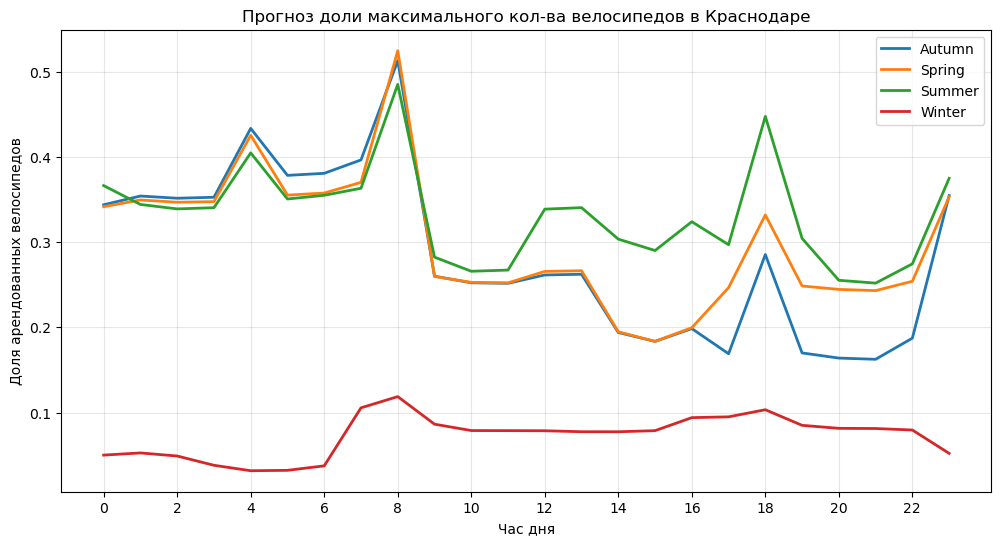

In [76]:
def create_krasnodar_grid(rf_model, X_train_r, park_size=1000):
    base_means = X_train_r.mean().to_dict()
    season_conditions = {
        'Winter': {'Temperature': 2, 'Humidity': 78, 'Rainfall': 0.5, 'Snowfall': 0.1, 'Radiation': 1.8},
        'Spring': {'Temperature': 15, 'Humidity': 70, 'Rainfall': 0.2, 'Snowfall': 0.0, 'Radiation': 4.5},
        'Summer': {'Temperature': 28, 'Humidity': 64, 'Rainfall': 0.1, 'Snowfall': 0.0, 'Radiation': 6.0},
        'Autumn': {'Temperature': 14, 'Humidity': 75, 'Rainfall': 0.3, 'Snowfall': 0.0, 'Radiation': 3.5}
    }
    rows = []
    for season, weather in season_conditions.items():
        for hour in range(24):
            row = base_means.copy()
            row['hour_sin'] = np.sin(2 * np.pi * hour / 24)
            row['hour_cos'] = np.cos(2 * np.pi * hour / 24)
            row['Temperature'] = weather['Temperature']
            row['Humidity'] = weather['Humidity']
            row['Rainfall'] = weather['Rainfall']
            row['Snowfall'] = weather['Snowfall']
            row['Radiation'] = weather['Radiation']
            row['Autumn'] = 1 if season == 'Autumn' else 0
            row['Spring'] = 1 if season == 'Spring' else 0
            row['Summer'] = 1 if season == 'Summer' else 0
            row['Winter'] = 1 if season == 'Winter' else 0
            row['Season'] = season
            row['Hour'] = hour

            rows.append(row)
    grid_df = pd.DataFrame(rows)
    grid_df = grid_df[X_train_r.columns.tolist() + ['Hour', 'Season']]
    predictions = rf_model.predict(grid_df[X_train_r.columns])
    grid_df['predicted_share'] = predictions
    #grid_df['predicted_count'] = (predictions * park_size).astype(int)

    return grid_df

krasnodar_grid = create_krasnodar_grid(rf_r, X_train_r, park_size=1000)
pivot_df = krasnodar_grid.pivot_table(
    index='Hour',
    columns='Season',
    values='predicted_share'
)
print("Прогноз спроса на велосипеды в Краснодаре:")
print(pivot_df.round(3))


plt.figure(figsize=(12, 6))
for season in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[season], label=season, linewidth=2)

plt.title('Прогноз доли максимального кол-ва велосипедов в Краснодаре')
plt.xlabel('Час дня')
plt.ylabel('Доля арендованных велосипедов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24, 2))
plt.show()

На графике продемонстрировано, что  пик спроса утром с 8-9 часов и вечером  с 17 часов - люди едут на работу/учебу и обратно.
Летом спрос выше, чем зимой - теплая погода способствует велопрогулкам.

В ночное время спрос минимальный.

Таким образом наша модель может предсказывать спрос в зависимости от погоды и времени суток.

## Инсайты для бизнеса


*   Летом:

Открывать прокат нужно в 7, чтобы поймать утреннюю волну спроса. С 9 до 11 проводить техосмотры и заниматься не связанными с прокатом вещами. Летом спрос будет поддерживаться на хорошем уровне до вечерней волны с 17 до 19. В районе 19 вечера в любое время года имеет смысл прекращать выдачу велосипедов.

Отметим, что эти пики вероятно связаны с рабочими часами, и мне не знаем, насколько клиенты привыкли так добираться до работы, насколько развита велокультура в городе, но мы можем продвигать эту идею через рекламу, чтобы потенциально выйти на эти пики.

*   Осенью и весной

Аналогично лету, но во второй половине дня мы ожидаем упадок спроса вплоть до небольшого вечернего повышения спроса. Часы работы персонала осенью и весной можно сократить, а с 14 до 16 можно обновлять шины на велосипедах на зимнюю резину, к примеру.

*   Зимой

Штат можно сократить до возможного минимума. На зиму следует продумать бизнес-стратегию, возможно, предоставлять услуги по хранению частных велосипедов или рассмотреть прокат другого сезонного транспорта.

*   "Ночной" спрос

Доля оставшихся "ночевать" не в прокате велосипедов сильно выше осенью, летом и весной по сравнению с зимой. Это значит, что на эти три сезона найдутся желающие брать велосипеды в долгосрочную аренду или лизинг, чтобы утром не думать о транспорте. Это потенциальная ниша, причем очень прибыльная как таковая и засчет доп. услуг.

Отметим, что зимой "ночующих" велосипедов практически нет - клиенты берут и возвращают велосипеды в течение дня.

*   Реальные данные

Единожды у нас появятся реальные данные заказов, мы сможем скорректировать и значительно уточнить прогноз, чтобы максимизировать прибыль и минимизировать потери, и выдавать как долгосрочный, так и среднесрочный прогноз по работе сервиса.

**Спасибо за внимание!**